# Exponential Smoothing and Holt-Winters Forecasting

This notebook continues from the ARIMA/SARIMA modeling notebook.

The goal is to test another family of classical forecasting models using the same daily `unit_sales` time series.

In the previous notebook, SARIMA and SARIMAX were used to model the weekly sales pattern. In this notebook, I use exponential smoothing methods as another classical forecasting approach.

Unlike ARIMA/SARIMA, exponential smoothing models do not use ACF and PACF plots to select parameters. Instead, they smooth the level, trend, and seasonal components of the series.

I will compare several methods, starting from simple baselines and moving toward Holt-Winters, which includes seasonality.

## Step 1 — Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from pathlib import Path

from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 2 — Load the feature dataset

This dataset was created in the previous feature engineering notebook and saved in the `outputs` folder.

In [4]:
features_path = Path("../outputs/timeseries_with_features.csv")

print("Path:", features_path.resolve())
print("Exists:", features_path.exists())

df = pd.read_csv(features_path, parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
print("Date range:", df["date"].min(), "to", df["date"].max())

display(df.head())

Path: /home/ana/cosas_eukene/accounts/github/time_series_analysis_ona/outputs/timeseries_with_features.csv
Exists: True
Dataset loaded successfully.
Shape: (424, 31)
Date range: 2013-02-01 00:00:00 to 2014-03-31 00:00:00


,date,unit_sales,day_of_week,day_number,month,year,is_weekend,rolling_7d,zscore,is_outlier,...,lag_7,lag_14,lag_30,rolling_7d_mean,rolling_14d_mean,rolling_30d_mean,rolling_7d_std,oil_lag_1,oil_lag_7,oil_rolling_7d_mean
0,2013-02-01,401.0,Friday,4,2,2013,0,456.285714,-0.444388,False,...,389.0,60.0,582.0,454.571429,497.071429,520.833333,154.059358,97.65,95.15,96.378571
1,2013-02-02,775.0,Saturday,5,2,2013,1,467.428571,1.714749,False,...,697.0,667.0,310.0,456.285714,521.428571,514.800000,153.272866,97.46,95.15,96.708571
2,2013-02-03,855.0,Sunday,6,2,2013,1,501.571429,2.176596,False,...,616.0,1090.0,338.0,467.428571,529.142857,530.300000,174.986530,97.46,95.15,97.038571
3,2013-02-04,411.0,Monday,0,2,2013,0,514.857143,-0.386657,False,...,318.0,760.0,654.0,501.571429,512.357143,547.533333,224.981375,97.46,95.95,97.368571
4,2013-02-05,272.0,Tuesday,1,2,2013,0,497.571429,-1.189117,False,...,393.0,461.0,979.0,514.857143,487.428571,539.433333,214.852219,96.21,97.62,97.405714


## Step 3 — Prepare the time series

For exponential smoothing models, the target should be indexed by date and follow a regular frequency.

In [5]:
ts = df[["date", "unit_sales"]].copy()

ts = (
    ts
    .set_index("date")
    .asfreq("D")
)

print("Time series frequency:", ts.index.freq)
print("Missing values:")
print(ts.isna().sum())

display(ts.head())

Time series frequency: <Day>
Missing values:
unit_sales    0
dtype: int64


,unit_sales
date,
2013-02-01,401.0
2013-02-02,775.0
2013-02-03,855.0
2013-02-04,411.0
2013-02-05,272.0


The target variable `unit_sales` was selected and indexed by date.

A daily frequency was enforced using `asfreq("D")`. The validation confirms that the series has a regular daily frequency and contains no missing values, so it can be used directly for exponential smoothing models.

## Step 4 — Visualize the sales series

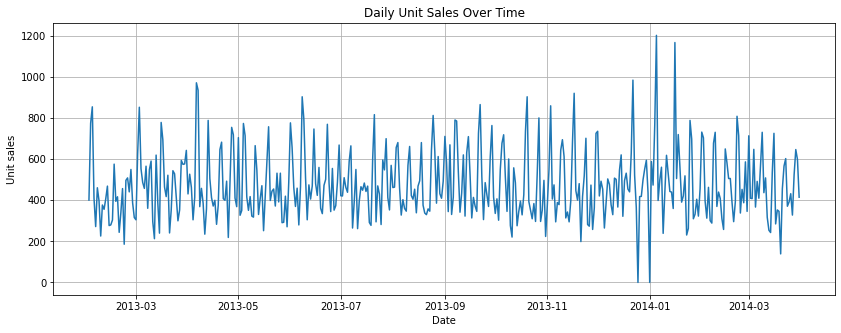

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(ts.index, ts["unit_sales"])
plt.title("Daily Unit Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Unit sales")
plt.grid(True)
plt.show()

The series shows a lot of day-to-day variation, with frequent spikes and drops in sales.

There is a visible weekly pattern, although it is not perfectly regular. There is no clear long-term trend, but the data is quite noisy, which is typical for daily retail sales.

Because of this, the series is a good candidate for Holt-Winters, since it can capture repeating seasonal patterns like the weekly cycle.

## Step 5 — Train/test split

The split must respect chronological order.

In [8]:
test_size = int(len(ts) * 0.2)

train = ts.iloc[:-test_size].copy()
test = ts.iloc[-test_size:].copy()

print("Training set:", train.index.min(), "to", train.index.max(), "| rows:", len(train))
print("Test set:", test.index.min(), "to", test.index.max(), "| rows:", len(test))

Training set: 2013-02-01 00:00:00 to 2014-01-06 00:00:00 | rows: 340
Test set: 2014-01-07 00:00:00 to 2014-03-31 00:00:00 | rows: 84


The data is split while keeping the chronological order.

I use the first 80% of the data for training and the last 20% for testing. This way, the model is evaluated on future data it has not seen before.

The test set covers about 12 weeks, which is useful to see how well the models capture the weekly pattern.

## Step 6 — Create evaluation function

In [15]:
def evaluate_forecast(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"{model_name}")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.4f}\n")

    return {
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

## Step 7 — Naive forecast baseline

The naive forecast repeats the last observed value from the training set.

In [16]:
last_value = train["unit_sales"].iloc[-1]

naive_predictions = pd.Series(
    [last_value] * len(test),
    index=test.index
)

naive_results = evaluate_forecast(
    "Naive Forecast",
    test["unit_sales"],
    naive_predictions
)

Naive Forecast
MAE: 135.25
RMSE: 185.00
R²: -0.1960



The naive forecast just repeats the last value from the training set.

As expected, it performs quite poorly, with a negative R² score. This means it is even worse than a simple baseline like predicting the average.

It does not capture any real structure in the data. The weekly pattern is completely ignored, and the forecast ends up being a flat line that does not follow the actual sales.

Even though the results are poor, this is a useful baseline. Any model we build next should clearly improve on this.

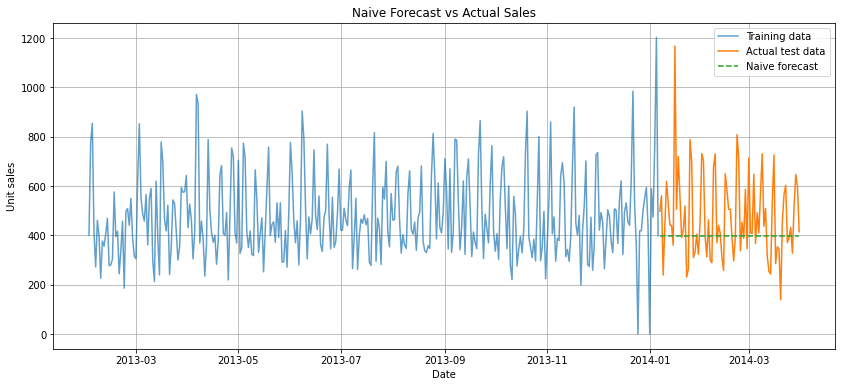

In [17]:
plt.figure(figsize=(14, 6))
plt.plot(train.index, train["unit_sales"], label="Training data", alpha=0.7)
plt.plot(test.index, test["unit_sales"], label="Actual test data")
plt.plot(test.index, naive_predictions, label="Naive forecast", linestyle="--")

plt.title("Naive Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Unit sales")
plt.legend()
plt.grid(True)
plt.show()

Even though the naive forecast performs poorly, it is still useful as a baseline. Any model we keep should clearly improve on it.

## Step 8 — Moving average baseline

This forecast uses the average of the last 7 training days.

In [18]:
window = 7

moving_average_value = train["unit_sales"].iloc[-window:].mean()

moving_average_predictions = pd.Series(
    [moving_average_value] * len(test),
    index=test.index
)

moving_average_results = evaluate_forecast(
    "Moving Average Forecast (7 days)",
    test["unit_sales"],
    moving_average_predictions
)

Moving Average Forecast (7 days)
MAE: 157.17
RMSE: 186.56
R²: -0.2163



The moving average forecast uses the average of the last 7 days from the training set.

In this case, it performs worse than the naive forecast, with higher MAE and a more negative R² score.

Even though it uses more information than the naive approach, it smooths the data too much and fails to react to recent changes. As a result, it does not capture the variability or the weekly pattern in the series.

This shows that simple smoothing methods are not enough for this type of data.

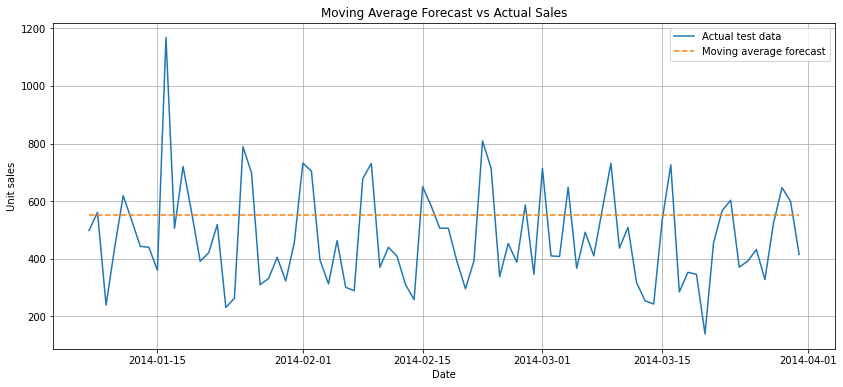

In [19]:
plt.figure(figsize=(14, 6))
plt.plot(test.index, test["unit_sales"], label="Actual test data")
plt.plot(test.index, moving_average_predictions, label="Moving average forecast", linestyle="--")

plt.title("Moving Average Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Unit sales")
plt.legend()
plt.grid(True)
plt.show()

The moving average forecast is a flat line, since it uses a single average value from the last 7 days.

Here, the forecast stays around a constant level and does not react to the large fluctuations in the data. The actual sales vary a lot, but the model cannot follow those changes.

This explains why the performance is worse than the naive forecast. By averaging the data, the model smooths too much and loses important patterns in the series.

## Step 9 — Simple Exponential Smoothing

In [20]:
ses_model = SimpleExpSmoothing(
    train["unit_sales"],
    initialization_method="estimated"
)

ses_fit = ses_model.fit(optimized=True)

ses_predictions = ses_fit.forecast(steps=len(test))
ses_predictions = ses_predictions.clip(lower=0)

ses_results = evaluate_forecast(
    "Simple Exponential Smoothing",
    test["unit_sales"],
    ses_predictions
)

Simple Exponential Smoothing
MAE: 147.64
RMSE: 177.71
R²: -0.1036



Simple Exponential Smoothing performs slightly better than the moving average, but it is still worse than the naive forecast.

The model reacts more to recent values, which helps a bit, but it still fails to capture the structure of the series.

This is because SES only models the level and does not account for seasonality. Since the data shows a clear weekly pattern, the model is not able to follow the ups and downs in the series.

Overall, the improvement is limited, and more advanced models are needed.

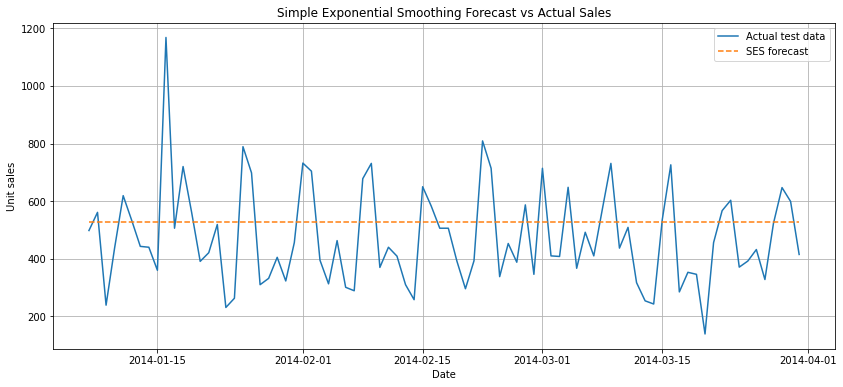

In [21]:
plt.figure(figsize=(14, 6))
plt.plot(test.index, test["unit_sales"], label="Actual test data")
plt.plot(test.index, ses_predictions, label="SES forecast", linestyle="--")

plt.title("Simple Exponential Smoothing Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Unit sales")
plt.legend()
plt.grid(True)
plt.show()

The SES forecast is no longer completely flat and reacts slightly to recent values.

However, it remains too smooth and stays around an average level. It does not follow the sharp peaks and drops in sales, and the weekly pattern is not captured.

Overall, the model misses most of the variability in the data, which explains why the improvement in performance is limited.

## Step 10 — Double Exponential Smoothing

In [22]:
double_model = ExponentialSmoothing(
    train["unit_sales"],
    trend="add",
    seasonal=None,
    initialization_method="estimated"
)

double_fit = double_model.fit(optimized=True)

double_predictions = double_fit.forecast(steps=len(test))
double_predictions = double_predictions.clip(lower=0)

double_results = evaluate_forecast(
    "Double Exponential Smoothing",
    test["unit_sales"],
    double_predictions
)

Double Exponential Smoothing
MAE: 480.89
RMSE: 547.76
R²: -9.4854



Double Exponential Smoothing performs significantly worse than the previous models.

The model introduces a trend component, but the series does not show a clear long-term trend. As a result, the model tries to fit a trend where none exists, leading to very poor forecasts.

This causes large errors and a highly negative R² score. Instead of improving the model, adding a trend component makes the predictions much worse.

This confirms that the main issue in this time series is not the trend, but the seasonal pattern.

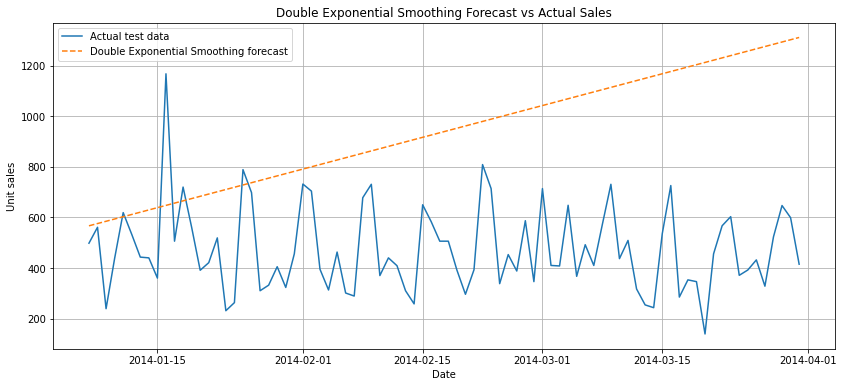

In [23]:
plt.figure(figsize=(14, 6))
plt.plot(test.index, test["unit_sales"], label="Actual test data")
plt.plot(test.index, double_predictions, label="Double Exponential Smoothing forecast", linestyle="--")

plt.title("Double Exponential Smoothing Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Unit sales")
plt.legend()
plt.grid(True)
plt.show()

The Double Exponential Smoothing forecast shows a strong upward trend that is not present in the actual data.

The model tries to fit a trend component, but the series does not have a clear long-term trend. As a result, the predictions drift away over time and become increasingly unrealistic.

This leads to very large errors and explains the poor performance of the model. Instead of improving the forecast, adding a trend component makes the results significantly worse.

## Step 11 — Holt-Winters model with weekly seasonality

In [24]:
hw_model = ExponentialSmoothing(
    train["unit_sales"],
    trend=None,
    seasonal="add",
    seasonal_periods=7,
    initialization_method="estimated"
)

hw_fit = hw_model.fit(optimized=True)

hw_predictions = hw_fit.forecast(steps=len(test))
hw_predictions = hw_predictions.clip(lower=0)

hw_results = evaluate_forecast(
    "Holt-Winters Additive Seasonality",
    test["unit_sales"],
    hw_predictions
)

Holt-Winters Additive Seasonality
MAE: 99.44
RMSE: 142.27
R²: 0.2926



The Holt-Winters model shows a clear improvement compared to the previous methods.

By including a seasonal component with a weekly period, the model is able to capture the repeating pattern in the data. This results in a significant reduction in error compared to the baseline models.

Although the performance is much better, the model still struggles with sharp peaks and sudden drops in sales. The forecasts remain smoother than the actual data, which is expected for this type of model.

Overall, this confirms that seasonality is an important factor in this time series and must be included to achieve reasonable forecasts.

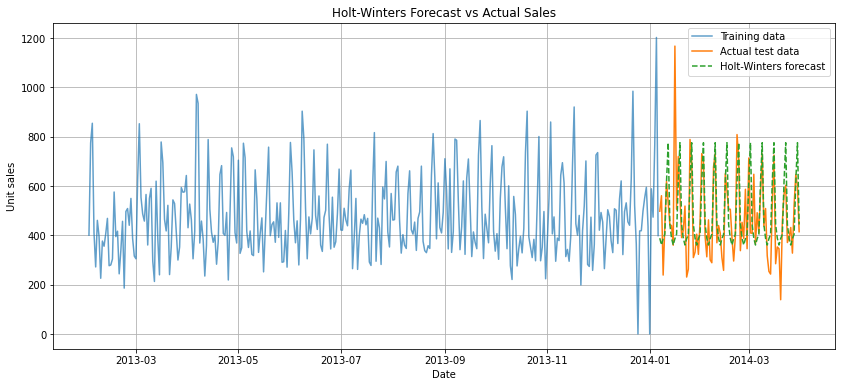

In [26]:
plt.figure(figsize=(14, 6))
plt.plot(train.index, train["unit_sales"], label="Training data", alpha=0.7)
plt.plot(test.index, test["unit_sales"], label="Actual test data")
plt.plot(test.index, hw_predictions, label="Holt-Winters forecast", linestyle="--")

plt.title("Holt-Winters Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Unit sales")
plt.legend()
plt.grid(True)
plt.show()

The Holt-Winters forecast clearly captures the weekly pattern in the data, with repeating ups and downs over time.

Unlike the previous models, the forecast now follows the general shape of the series and reacts to the seasonal structure. This explains the significant improvement in performance.

However, the predictions are still smoother than the actual values and do not fully capture the sharp peaks and drops in sales.

Overall, the model provides a much more realistic forecast, confirming that seasonality is a key component in this time series.

## Step 12 — Compare additive vs multiplicative seasonality

In [27]:
hw_add_model = ExponentialSmoothing(
    train["unit_sales"],
    trend=None,
    seasonal="add",
    seasonal_periods=7,
    initialization_method="estimated"
)

hw_add_fit = hw_add_model.fit(optimized=True)
hw_add_predictions = hw_add_fit.forecast(steps=len(test)).clip(lower=0)

hw_mul_results = None
try:
    hw_mul_model = ExponentialSmoothing(
        train["unit_sales"],
        trend=None,
        seasonal="mul",
        seasonal_periods=7,
        initialization_method="estimated"
    )

    hw_mul_fit = hw_mul_model.fit(optimized=True)
    hw_mul_predictions = hw_mul_fit.forecast(steps=len(test)).clip(lower=0)

    hw_mul_results = evaluate_forecast(
        "Holt-Winters Multiplicative",
        test["unit_sales"],
        hw_mul_predictions
    )

except Exception as e:
    print("Multiplicative Holt-Winters failed:", e)
    hw_mul_predictions = None

hw_add_results = evaluate_forecast(
    "Holt-Winters Additive",
    test["unit_sales"],
    hw_add_predictions
)

Multiplicative Holt-Winters failed: endog must be strictly positive when usingmultiplicative trend or seasonal components.
Holt-Winters Additive
MAE: 99.44
RMSE: 142.27
R²: 0.2926



The multiplicative Holt-Winters model could not be applied because the series contains zero or very low values. This type of model requires strictly positive data, which is not the case here.

As a result, only the additive version was used.

The additive Holt-Winters model performs well and captures the weekly pattern in the data. Given the nature of this time series, additive seasonality is more appropriate than multiplicative.

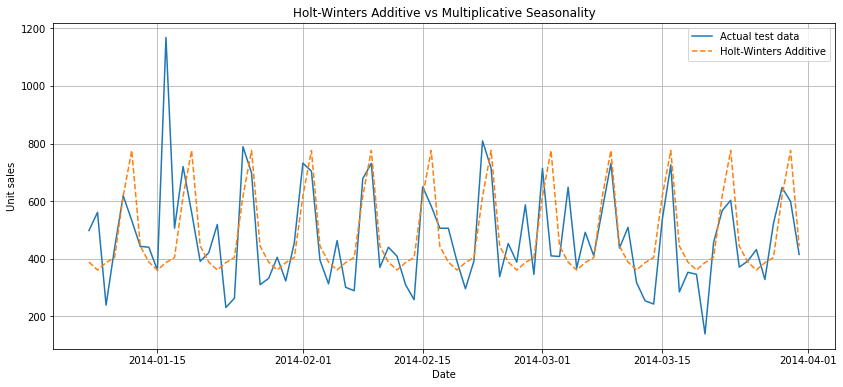

In [28]:
plt.figure(figsize=(14, 6))
plt.plot(test.index, test["unit_sales"], label="Actual test data")
plt.plot(test.index, hw_add_predictions, label="Holt-Winters Additive", linestyle="--")

if hw_mul_predictions is not None:
    plt.plot(test.index, hw_mul_predictions, label="Holt-Winters Multiplicative", linestyle="--")

plt.title("Holt-Winters Additive vs Multiplicative Seasonality")
plt.xlabel("Date")
plt.ylabel("Unit sales")
plt.legend()
plt.grid(True)
plt.show()

The additive Holt-Winters model captures the weekly pattern in the data, with clear and consistent oscillations over time.

The forecasts follow the general shape of the series, although they remain smoother than the actual values and do not fully capture sharp peaks and drops.

The multiplicative version could not be applied due to the presence of zero or very low values in the series.

Overall, the additive model provides a good balance between simplicity and performance, and is the most suitable exponential smoothing approach for this dataset.

## Step 13 — Compare all exponential smoothing models

In [29]:
all_results = [
    naive_results,
    moving_average_results,
    ses_results,
    double_results,
    hw_add_results
]

if hw_mul_results is not None:
    all_results.append(hw_mul_results)

results_exp_smoothing = pd.DataFrame(all_results)
results_exp_smoothing = results_exp_smoothing.sort_values("MAE").reset_index(drop=True)

display(results_exp_smoothing)

,model,MAE,RMSE,R2
0,Holt-Winters Additive,99.443942,142.272875,0.292630
1,Naive Forecast,135.250000,184.997844,-0.196012
2,Simple Exponential Smoothing,147.636675,177.709799,-0.103634
3,Moving Average Forecast (7 days),157.171769,186.562536,-0.216329
4,Double Exponential Smoothing,480.887185,547.760426,-9.485366


The comparison shows a clear difference in performance across the models.

The Holt-Winters model with additive seasonality performs best, with the lowest MAE and a positive R² score. This confirms that including the weekly seasonal pattern is essential for this dataset.

All other models perform significantly worse. The naive, moving average, and simple exponential smoothing approaches fail to capture the structure of the series. Double Exponential Smoothing performs particularly poorly, as it introduces a trend component that is not present in the data.

Overall, these results highlight that seasonality is the main driver of this time series, and must be included to obtain meaningful forecasts.

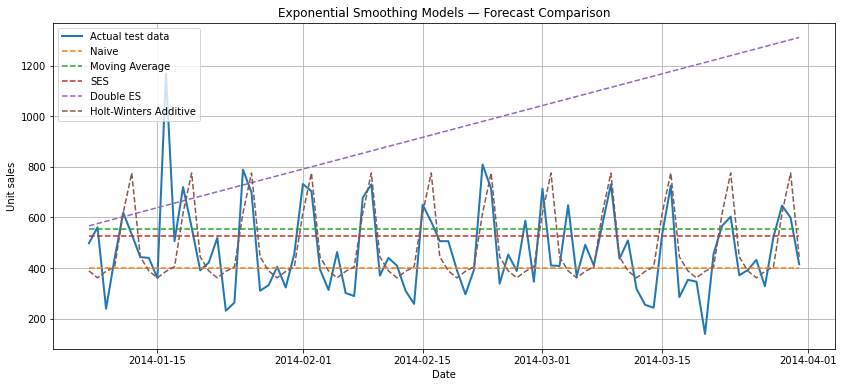

In [30]:
plt.figure(figsize=(14, 6))

plt.plot(test.index, test["unit_sales"], label="Actual test data", linewidth=2)

plt.plot(test.index, naive_predictions, label="Naive", linestyle="--")
plt.plot(test.index, moving_average_predictions, label="Moving Average", linestyle="--")
plt.plot(test.index, ses_predictions, label="SES", linestyle="--")
plt.plot(test.index, double_predictions, label="Double ES", linestyle="--")
plt.plot(test.index, hw_add_predictions, label="Holt-Winters Additive", linestyle="--")

if hw_mul_predictions is not None:
    plt.plot(test.index, hw_mul_predictions, label="Holt-Winters Multiplicative", linestyle="--")

plt.title("Exponential Smoothing Models — Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Unit sales")
plt.legend()
plt.grid(True)
plt.show()

This comparison highlights the differences between all exponential smoothing models.

The simpler methods, including the naive forecast, moving average, and simple exponential smoothing, produce flat or nearly flat predictions and fail to capture the variability in the data.

Double Exponential Smoothing performs particularly poorly, as it introduces a trend that is not present in the series, causing the forecast to drift away over time.

In contrast, the Holt-Winters model with additive seasonality clearly stands out. It captures the weekly pattern and follows the general shape of the data, providing much more realistic forecasts.

Overall, this confirms that including seasonality is essential for this time series.

## Step 14 — Compare with SARIMA/SARIMAX results

The SARIMA and SARIMAX results come from the previous notebook.

In [31]:
classical_results = pd.DataFrame([
    {
        "model": "SARIMA",
        "MAE": 96.98,
        "RMSE": 140.64,
        "R2": 0.3088
    },
    {
        "model": "SARIMAX",
        "MAE": 96.58,
        "RMSE": 139.85,
        "R2": 0.3165
    }
])

combined_results = pd.concat(
    [results_exp_smoothing, classical_results],
    ignore_index=True
)

combined_results = combined_results.sort_values("MAE").reset_index(drop=True)

display(combined_results)

,model,MAE,RMSE,R2
0,SARIMAX,96.580000,139.850000,0.316500
1,SARIMA,96.980000,140.640000,0.308800
2,Holt-Winters Additive,99.443942,142.272875,0.292630
3,Naive Forecast,135.250000,184.997844,-0.196012
4,Simple Exponential Smoothing,147.636675,177.709799,-0.103634
5,Moving Average Forecast (7 days),157.171769,186.562536,-0.216329
6,Double Exponential Smoothing,480.887185,547.760426,-9.485366


The comparison shows that SARIMAX performs best, with SARIMA very close behind.

Both models do better than the exponential smoothing ones, although the difference is not very large. Holt-Winters, even though it is simpler, still performs quite well and captures the main seasonal pattern in the data.

This suggests that more complex models can help, but once the seasonality is properly modeled, most of the useful signal is already captured.

Overall, the key factor across all models is the ability to capture the weekly pattern in the data.

## Summary

In this notebook, I tested different exponential smoothing methods on the daily `unit_sales` time series.

I started with simple baselines like the naive forecast and moving average, and then moved to more advanced methods such as Simple Exponential Smoothing, Double Exponential Smoothing, and Holt-Winters.

The simpler models mostly produced flat forecasts and were not able to capture the weekly pattern in the data. Holt-Winters performed much better because it includes a seasonal component, which turns out to be key for this dataset.

However, even Holt-Winters still produces smoother predictions than the actual data and struggles with sharp spikes and sudden drops. This is similar to what we saw with SARIMA and SARIMAX.

Overall, exponential smoothing methods provide a solid baseline, but they have limitations when the data is highly variable and noisy. This suggests that more flexible models, such as machine learning approaches, may perform better.

The next step is to compare these results with machine learning models such as XGBoost.